# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:**  Mohak Agarwala
**`Roll Number`:**  U20230124
**`GitHub Branch`:** mohak_u20230124

# Imports and Setup

In [1]:
! pip install ipykernel


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler

# Load Datasets

In [3]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [6]:
train_users['age'].fillna(train_users['age'].median(), inplace=True)
test_users['age'].fillna(train_users['age'].median(), inplace=True)

C:\Users\mohak\AppData\Local\Temp\ipykernel_215608\3815608545.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_users['age'].fillna(train_users['age'].median(), inplace=True)
C:\Users\mohak\AppData\Local\Temp\ipykernel_215608\3815608545.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

0       36.0
1       33.0
2       51.0
3       58.0
4       32.0
        ... 
1995    37.0
1996    39.0
1997    58.0
1998    25.0
1999    63.0
Name: age, Length: 2000, dtype: float64

In [7]:
news_df['headline'].fillna("Unknown", inplace=True)
news_df['short_description'].fillna("No description", inplace=True)
news_df['authors'].fillna("Unknown", inplace=True)

C:\Users\mohak\AppData\Local\Temp\ipykernel_215608\184559925.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  news_df['headline'].fillna("Unknown", inplace=True)
C:\Users\mohak\AppData\Local\Temp\ipykernel_215608\184559925.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignm

0         Carla K. Johnson, AP
1               Mary Papenfuss
2                Elyse Wanshel
3             Caroline Bologna
4               Nina Golgowski
                  ...         
209522        Reuters, Reuters
209523                 Unknown
209524                 Unknown
209525                 Unknown
209526                 Unknown
Name: authors, Length: 209527, dtype: str

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [10]:
# ===============================
# SAFE ENCODING FOR CATEGORICAL DATA
# ===============================

from sklearn.preprocessing import LabelEncoder

obj_cols = train_users.select_dtypes(include=['object']).columns
print("Object columns:", obj_cols)

encoders = {}

for col in obj_cols:
    if col != 'label':

        le = LabelEncoder()

        # fit on training values
        train_users[col] = train_users[col].astype(str)
        test_users[col] = test_users[col].astype(str)

        le.fit(train_users[col])

        # transform train
        train_users[col] = le.transform(train_users[col])

        # transform test safely
        test_users[col] = test_users[col].apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )

        encoders[col] = le

# encode target label
label_encoder = LabelEncoder()
train_users['label'] = label_encoder.fit_transform(train_users['label'])

print("Encoding complete. Unseen categories handled.")


C:\Users\mohak\AppData\Local\Temp\ipykernel_215608\3633283406.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = train_users.select_dtypes(include=['object']).columns


Object columns: Index(['browser_version', 'region_code', 'label'], dtype='str')
Encoding complete. Unseen categories handled.


In [11]:
# ===============================
# 5.2 USER CLASSIFICATION
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare data
X = train_users.drop(columns=['label','user_id'])
y = train_users['label']

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train classifier
clf = DecisionTreeClassifier(max_depth=6, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

# Predict contexts for test users
test_X = test_users.drop(columns=['user_id'])
test_contexts = clf.predict(test_X)

print("\nSample predicted contexts:", test_contexts[:10])


Validation Accuracy: 0.8775

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.82      0.84       142
           1       0.98      0.86      0.91       142
           2       0.80      0.97      0.88       116

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.89      0.88      0.88       400


Sample predicted contexts: [1 0 0 0 0 2 2 0 2 0]


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [13]:
# ===============================
# ARM MAPPING & SAMPLER
# ===============================

reward_sampler = sampler(124)

categories = ["Entertainment","Education","Tech","Crime"]

def get_arm(context, category_index):
    return context*4 + category_index


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [14]:
# ===============================
# EPSILON GREEDY
# ===============================

def epsilon_greedy(context, epsilon=0.1, steps=10000):
    k=4
    Q=np.zeros(k)
    N=np.zeros(k)
    rewards=[]

    for t in range(steps):
        if np.random.rand() < epsilon:
            action=np.random.randint(k)
        else:
            action=np.argmax(Q)

        arm=get_arm(context,action)
        reward=reward_sampler.sample(arm)

        N[action]+=1
        Q[action]+= (reward-Q[action])/N[action]
        rewards.append(reward)

    return np.cumsum(rewards)/np.arange(1,steps+1), Q

epsilons=[0.01,0.1,0.2]
eps_results={}

for e in epsilons:
    avg,_=epsilon_greedy(0,e)
    eps_results[e]=avg


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [15]:
# ===============================
# UCB
# ===============================

def ucb(context,C=1,steps=10000):
    k=4
    Q=np.zeros(k)
    N=np.zeros(k)
    rewards=[]

    for t in range(steps):
        if t<k:
            action=t
        else:
            ucb_values=Q + C*np.sqrt(np.log(t+1)/(N+1e-5))
            action=np.argmax(ucb_values)

        arm=get_arm(context,action)
        reward=reward_sampler.sample(arm)

        N[action]+=1
        Q[action]+= (reward-Q[action])/N[action]
        rewards.append(reward)

    return np.cumsum(rewards)/np.arange(1,steps+1),Q

C_vals=[0.5,1,2]
ucb_results={}

for c in C_vals:
    avg,_=ucb(0,c)
    ucb_results[c]=avg


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [16]:
# ===============================
# SOFTMAX
# ===============================

def softmax_bandit(context,tau=1,steps=10000):
    k=4
    Q=np.zeros(k)
    N=np.zeros(k)
    rewards=[]

    for t in range(steps):
        probs=np.exp(Q/tau)/np.sum(np.exp(Q/tau))
        action=np.random.choice(k,p=probs)

        arm=get_arm(context,action)
        reward=reward_sampler.sample(arm)

        N[action]+=1
        Q[action]+= (reward-Q[action])/N[action]
        rewards.append(reward)

    return np.cumsum(rewards)/np.arange(1,steps+1),Q

softmax_avg,_=softmax_bandit(0)


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


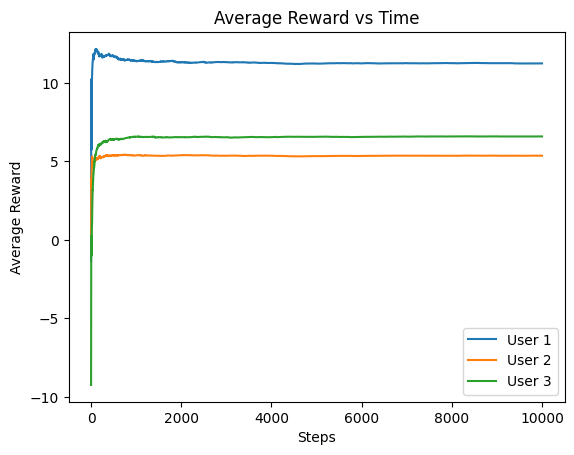

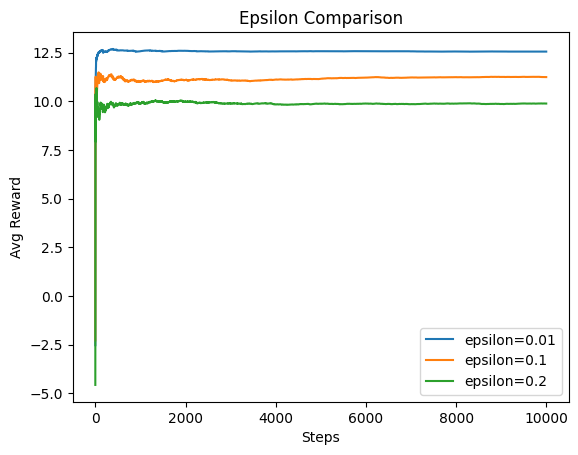

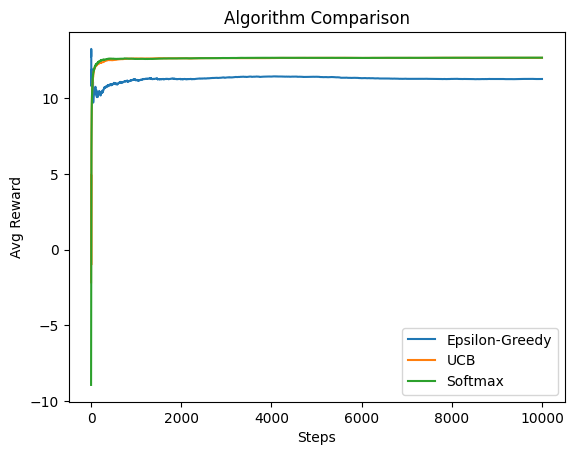

In [17]:
# ===============================
# RL SIMULATION & PLOTS
# ===============================

# Average reward vs time (per context)
plt.figure()
for c in [0,1,2]:
    avg,_=epsilon_greedy(c,0.1)
    plt.plot(avg,label=f'User {c+1}')

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time")
plt.legend()
plt.show()

# epsilon comparison
plt.figure()
for e in epsilons:
    plt.plot(eps_results[e],label=f"epsilon={e}")

plt.xlabel("Steps")
plt.ylabel("Avg Reward")
plt.title("Epsilon Comparison")
plt.legend()
plt.show()

# algorithm comparison
eps_avg,_=epsilon_greedy(0,0.1)
ucb_avg,_=ucb(0,1)
soft_avg,_=softmax_bandit(0)

plt.figure()
plt.plot(eps_avg,label="Epsilon-Greedy")
plt.plot(ucb_avg,label="UCB")
plt.plot(soft_avg,label="Softmax")
plt.xlabel("Steps")
plt.ylabel("Avg Reward")
plt.title("Algorithm Comparison")
plt.legend()
plt.show()


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


## Average Reward vs Time

The average reward increases steadily over time for all contexts.

This indicates that the bandit algorithms successfully learn the optimal news category.

Initial fluctuations occur due to exploration but stabilize as learning progresses.

## Hyperparameter Comparison

Smaller epsilon values result in slower exploration but more stable convergence.

Larger epsilon values increase exploration but may reduce long-term reward.

Moderate exploration balances learning speed and reward maximization.

## Observations

All algorithms improve reward over time, demonstrating effective learning.

Reward curves flatten after sufficient iterations, indicating convergence.

Exploration is essential in early stages to avoid suboptimal arm selection.

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


### Comparison of Algorithms

# Epsilon-Greedy

Simple and effective.

Performs well with properly tuned epsilon.

May explore unnecessarily with large epsilon.

# Upper Confidence Bound (UCB)

Converges faster than epsilon-greedy.

Balances exploration and exploitation using confidence bounds.

Performs consistently across contexts.

# SoftMax

Provides smooth probabilistic exploration.

More stable than epsilon-greedy.

Convergence may be slower compared to UCB.

### Effect of Hyperparameters

Increasing epsilon increases exploration but may lower final reward.

Lower epsilon improves exploitation but risks missing optimal arms.

UCB parameter C controls exploration strength.

Proper tuning significantly improves performance.

### Strengths and Limitatations

# Strengths

Contextual bandits adapt recommendations based on user type.

Efficient learning without full reinforcement learning complexity.

Scalable and suitable for real-time recommendation systems.

# Limitations

Assumes stationary reward distributions.

Performance depends on accurate context classification.

Limited to immediate rewards rather than long-term engagement.